In [80]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## One Sample T-test

tk = (mean(x) - mue) / (std(x)/sqrt(n))

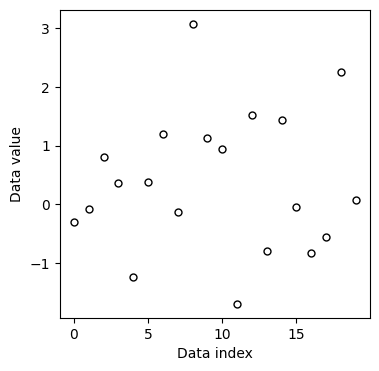

In [81]:
n = 20
population_mean = .5
sample = np.random.randn(n) + population_mean

fig_a, ax_a = plt.subplots(figsize=(4, 4))
ax_a.plot(sample, 'ko', markerfacecolor='w', markersize=5)
ax_a.set_xlabel('Data index')
ax_a.set_ylabel('Data value')

fig_a.show()

0.08487016592669894 0.08487016592669894
0.16974033185339787


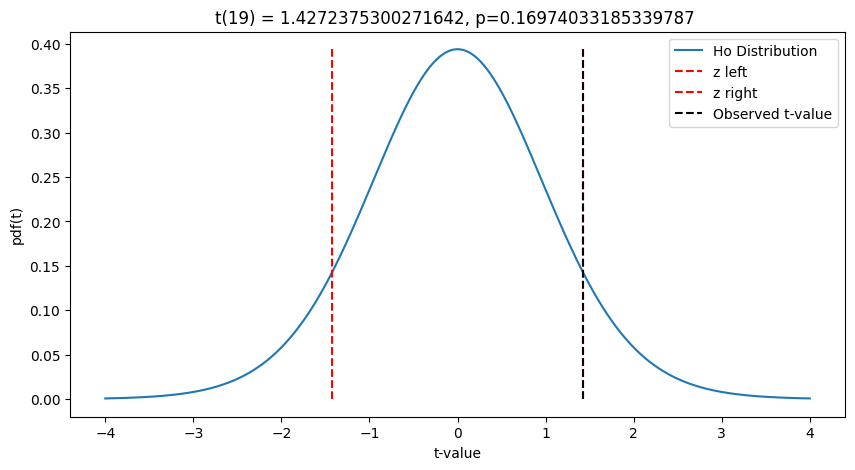

In [84]:
H0_mean = 0

t_num = np.mean(sample) - H0_mean
t_den = np.std(sample, ddof=1) / np.sqrt(n)
t = t_num / t_den

degrees_of_freedom = sample.size -1
right_t = np.abs(t)
left_t = -right_t

t_left = stats.t.cdf(left_t, degrees_of_freedom)
t_right = 1 - stats.t.cdf(right_t, degrees_of_freedom)

# Probability of t given normal distribution
# One tailed
p_one_tailed = t_right
# One tailed
p_two_tailed = t_left + t_right

z_scale = np.linspace(-4, 4, 1001)
t_distribution = stats.t.pdf(z_scale, degrees_of_freedom)

fig_b, ax_b = plt.subplot_mosaic([['pdf']], figsize=[10, 5])
ax_b['pdf'].plot(z_scale, t_distribution, '-')
ax_b['pdf'].plot([left_t, left_t], [0, max(t_distribution)], 'r--',)
ax_b['pdf'].plot([right_t, right_t], [0, max(t_distribution)], 'r--')
ax_b['pdf'].plot([t, t], [0, max(t_distribution)], 'k--')
ax_b['pdf'].legend(['Ho Distribution', 't left', 't right', 'Observed t-value'])

ax_b['pdf'].set_title(f"t({degrees_of_freedom}) = {t}, p={p_two_tailed} ")
ax_b['pdf'].set_xlabel('t-value')
ax_b['pdf'].set_ylabel('pdf(t)')

fig_b.show()


In [83]:
t, p_two_tailed = stats.ttest_1samp(sample, H0_mean, alternative='two-sided')
print(f"t({degrees_of_freedom}) = {t}, p={p_two_tailed})")

t(19) = 1.4272375300271642, p=0.16974033185339787)
